# 주식분석

Last updated 202501

## 목차

* 1. 주식분석
* 2. 데이터 수집
* 3. 기본 지표
* 4. 기술 지표
* 5. 성과 지표
* 6. 백테스트 backtesting.py
  7. 기계학습 백테스트
* 8. BackTrader
* 9. 주가보고서 작성: chatGPT
* 10. 주가 예측
* 11. 포트폴리오
* 12. 트레이딩 프로그램

## 참고
- advances in financial machine learning
- see hello_finance.ipynb

# 10. 주가 예측

주가 예측은 다양한 방법과 모델을 통해 향후 주가를 예측하려는 시도이다. 과거에는 기술적 분석과 기본적 분석에 의존해 예측하려 했지만, 최근에는 데이터의 양이 방대해지면서 기계학습과 딥러닝 같은 고도화된 기법들이 주목받고 있다.

주가 예측에서 활용되는 주요 접근 방법은 크게 세 가지로 나눌 수 있다.

1. 기술적 분석과 기본적 분석
- 기술적 분석: 과거 가격, 거래량, 차트 패턴 등의 시장 데이터를 이용해 주가 변동을 예측한다.
- 기본적 분석: 기업의 내재 가치를 평가하여 주가를 예측한다.

2. 통계적 모델
- 회귀모델: 주가와 독립 변수(금리, 경제 지표 등) 사이의 관계를 모델링해 예측하는 방식이다.
- 시계열 모델: 주가의 시간적 패턴을 분석하여 예측하는 방식이다.
    - ARIMA(Autoregressive Integrated Moving Average): 시계열의 자기상관성을 기반으로 예측
    - GARCH (Generalized Autoregressive Conditional Heteroskedasticity): 변동성이 크거나 작거나 반복되는 패턴을 바탕으로 미래 변동성을 예측

3. 기계학습 (Machine Learning)
- 랜덤 포레스트: 여러 개의 의사결정 트리를 결합하여 평균적으로 더 나은 예측을 만드는 앙상블 방법
- SVM (Support Vector Machine): 고차원 공간에서 데이터를 분류하는 기법으로, 주가가 오를지 내릴지 두 가지 상태로 분류하는 데 사용
- XGBoost: 의사결정 트리를 기반으로 한 부스팅 알고리즘으로, 학습 속도가 빠르고 성능이 우수해 금융 데이터 분석에 자주 활용
- DQN(Deep Q-Networks): 강화학습 기법 중 하나로, 주식의 매수/매도 타이밍을 게임 환경처럼 정의하고 최적의 행동을 학습
- PPO(Proximal Policy Optimization): 정책 기반 강화학습 기법으로, 시장의 복잡한 환경에서 지속적인 학습과 최적화를 수행하는 데 적합
- 딥러닝 (Deep Learning):
    - LSTM(Long Short-Term Memory): RNN(순환 신경망) 구조로, 장기 의존성을 고려하여 주가 예측에 적합
    - RNN(Recurrent Neural Networks)
    - CNN(Convolutional Neural Networks)


## 10.1 tensorFlow

pip install tensorflow

In [182]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### LSTM

### train

In [169]:
stock_data=sds

In [170]:
stock_data

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2021-01-04,188000.0,178500.0,179000.0,186000.0,542371.0,183235.906250
2021-01-05,219000.0,182000.0,186000.0,212500.0,1688082.0,209342.109375
2021-01-06,216500.0,202500.0,216000.0,203000.0,1101423.0,199983.281250
2021-01-07,212000.0,203000.0,206000.0,205000.0,644160.0,201953.562500
2021-01-08,229500.0,208000.0,209000.0,219500.0,1543681.0,216238.078125
...,...,...,...,...,...,...
2022-11-01,126000.0,123500.0,124000.0,124500.0,72726.0,124500.000000
2022-11-02,126000.0,123000.0,123500.0,125500.0,96724.0,125500.000000
2022-11-03,127000.0,122500.0,123000.0,125000.0,93461.0,125000.000000


In [172]:
close_prices = stock_data['Close']

In [173]:
values = close_prices.values

In [174]:
import math

training_data_len = math.ceil(len(values)* 0.8)

sklearn의 MinMaxScaler를 적용하자.
```pip install sklearn```

In [175]:
from sklearn.preprocessing import MinMaxScaler 

scaler = MinMaxScaler(feature_range=(0,1))

reshape(-1, n)의 행을 -1로 하면, 열의 'n'의 수에 맞추어 행의 차원이 가변적으로 설정된다.

설명보다 직접 보면 이해가 빠르겠다.

```
array([186000., 212500., 203000., ...생략..., 125000., 126000.])    
```

를 reshape(-1, 1)하면
```
array([[0.68544601],
       [0.9342723 ],
       [0.84507042],
       
      [0.11267606],
       [0.12206573]])
```

열=1 차원으로 행이 설정된다는 말이다.

In [176]:
scaled_data = scaler.fit_transform(values.reshape(-1,1))

scaled_data

In [180]:
import numpy as np

train_data = scaled_data[0: training_data_len, :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [181]:
x_train

array([[[0.68544601],
        [0.9342723 ],
        [0.84507042],
        ...,
        [0.69953052],
        [0.76995305],
        [0.75586854]],

       [[0.9342723 ],
        [0.84507042],
        [0.86384977],
        ...,
        [0.76995305],
        [0.75586854],
        [0.73239437]],

       [[0.84507042],
        [0.86384977],
        [1.        ],
        ...,
        [0.75586854],
        [0.73239437],
        [0.72769953]],

       ...,

       [[0.16431925],
        [0.17840376],
        [0.21126761],
        ...,
        [0.1971831 ],
        [0.21126761],
        [0.16431925]],

       [[0.17840376],
        [0.21126761],
        [0.20187793],
        ...,
        [0.21126761],
        [0.16431925],
        [0.15023474]],

       [[0.21126761],
        [0.20187793],
        [0.23943662],
        ...,
        [0.16431925],
        [0.15023474],
        [0.16431925]]])

### 테스트 데이터

In [186]:
test_data = scaled_data[training_data_len-60: , : ]
x_test = []
y_test = values[training_data_len:]

for i in range(60, len(test_data)):
  x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

### LSTM 네트워크 아키텍쳐 설정

In [183]:
model = keras.Sequential()
model.add(layers.LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.LSTM(100, return_sequences=False))
model.add(layers.Dense(25))
model.add(layers.Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 100)           40800     
                                                                 
 lstm_1 (LSTM)               (None, 100)               80400     
                                                                 
 dense (Dense)               (None, 25)                2525      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 123,751
Trainable params: 123,751
Non-trainable params: 0
_________________________________________________________________


### 훈련

In [184]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size= 1, epochs=3)

Epoch 1/3
304/304 [==============================] - 11s 23ms/step - loss: 0.0053
Epoch 2/3
304/304 [==============================] - 7s 23ms/step - loss: 0.0026
Epoch 3/3
304/304 [==============================] - 7s 23ms/step - loss: 0.0018


### 평가

In [187]:
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
rmse = np.sqrt(np.mean(predictions - y_test)**2)
rmse

3/3 [==============================] - 1s 34ms/step


575.9889756944444

### 시각화

In [190]:
data = stock_data.filter(['Close'])
train = data[:training_data_len]
validation = data[training_data_len:]

복사해서 사용하지 않으니 경고
```Warning : Try using .loc[row_indexer,col_indexer] = value instead```

In [193]:
validation = validation.copy() ## 복사해서 사용하지 않으니 경고
Warning : Try using .loc[row_indexer,col_indexer] = value instead 

In [194]:
validation['Predictions'] = predictions

<IPython.core.display.Javascript object>


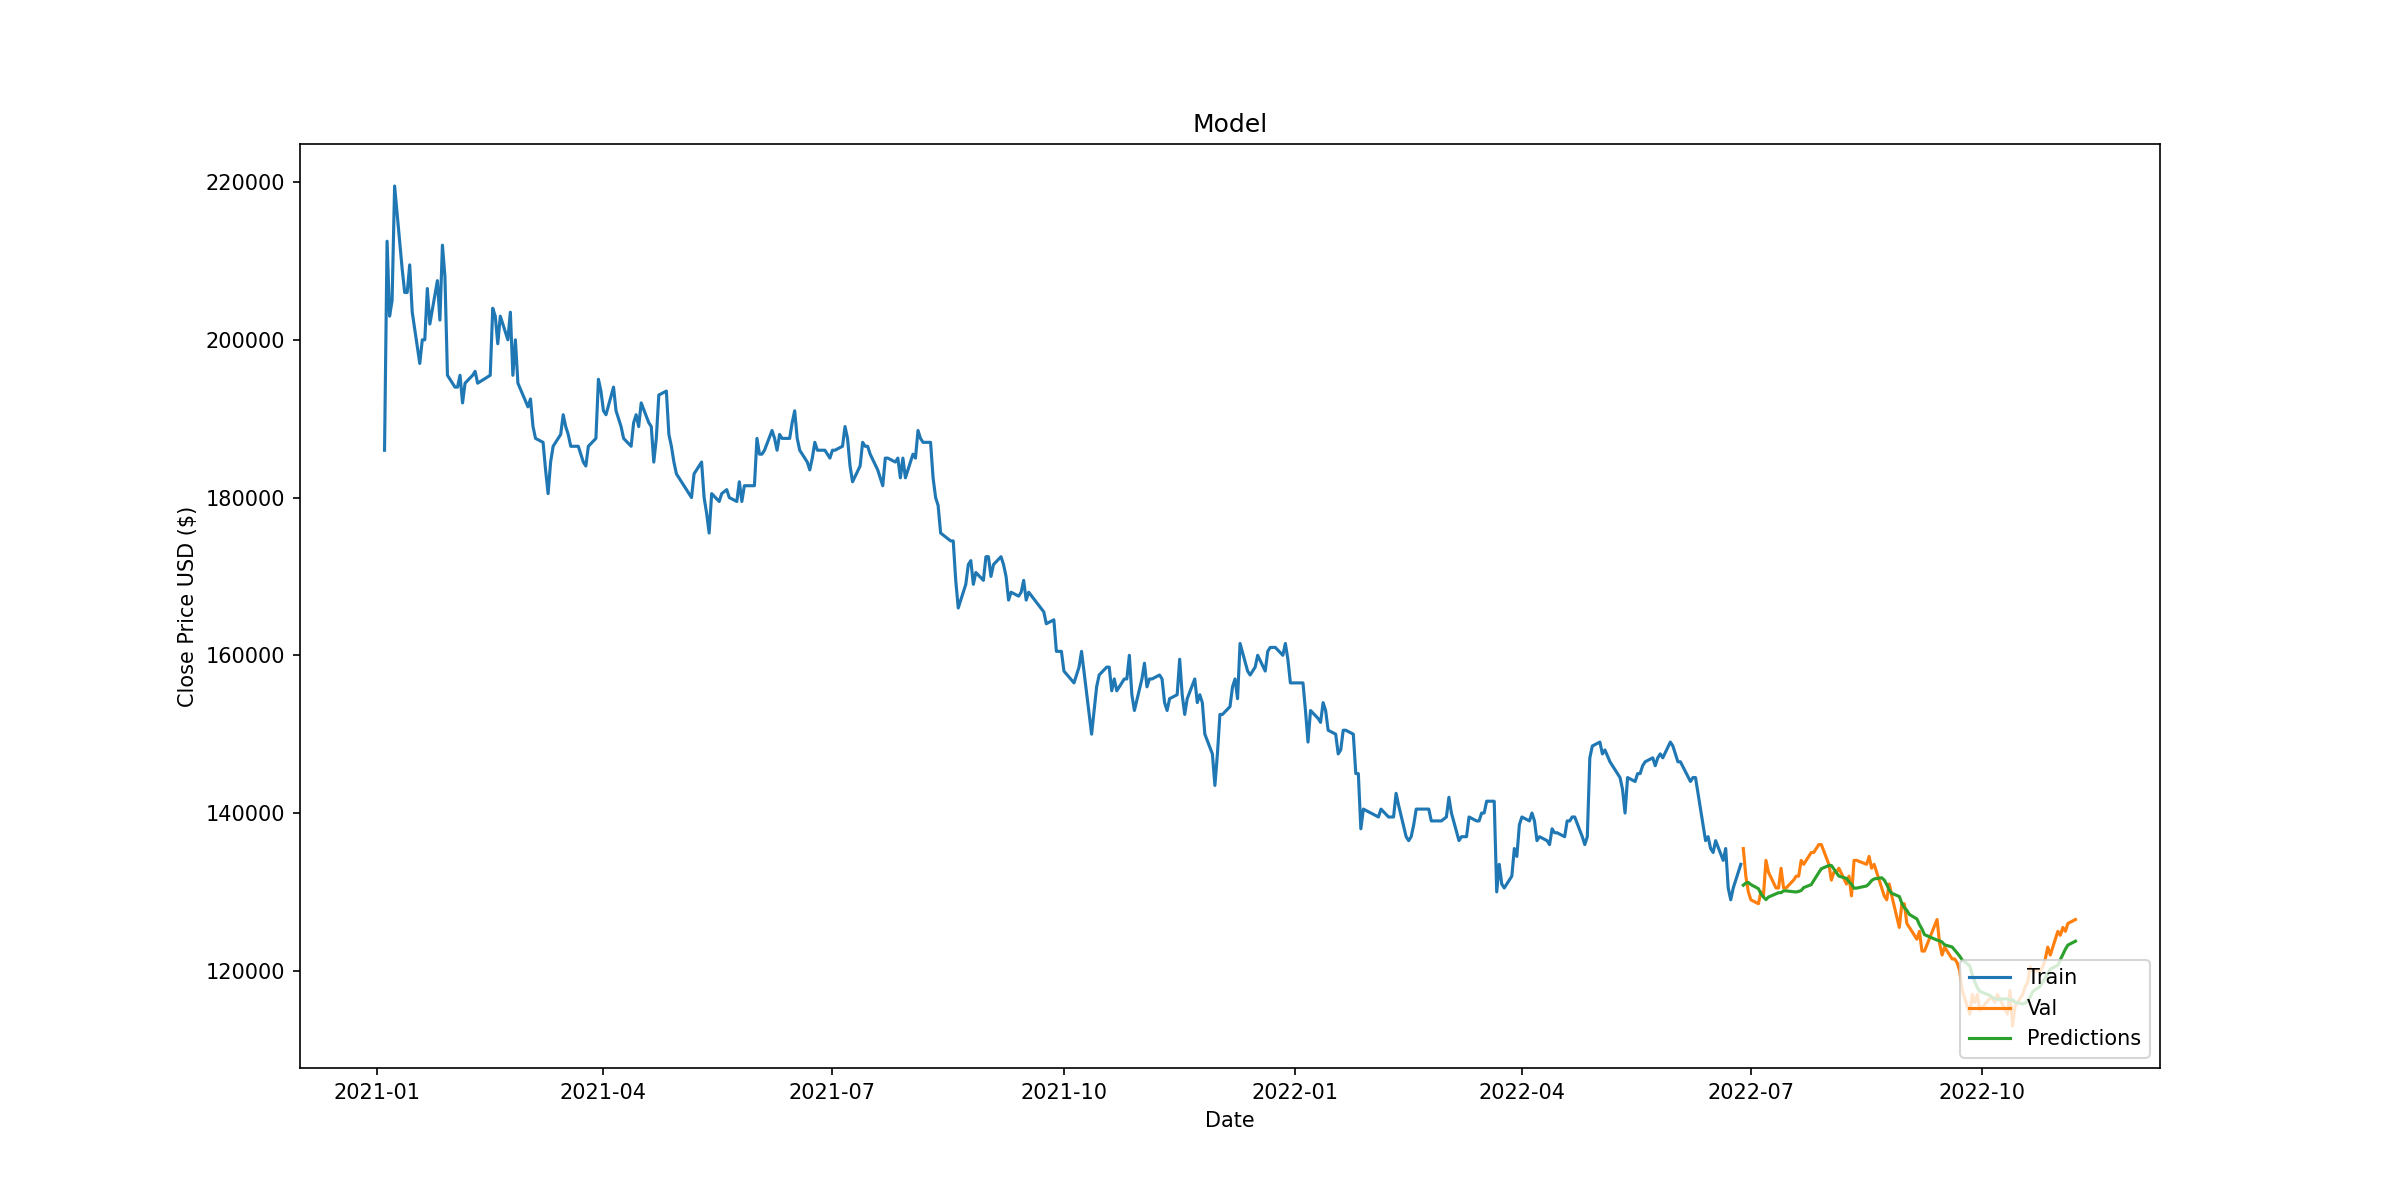

In [195]:
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(train)
plt.plot(validation[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

https://medium.com/the-handbook-of-coding-in-finance/stock-prices-prediction-using-long-short-term-memory-lstm-model-in-python-734dd1ed6827

# 11. 포트폴리오

## 11.1 라이브러리

포트폴리오 최적화는 위험 대비 수익을 극대화하는 자산의 구성을 위해 사용하는데, 라이브러리는 다음과 같다. 

- PyPortfolioOpt는 마코위츠의 현대 포트폴리오 이론(MPT)을 기반으로 다양한 최적화 기법을 제공한다. 
- Riskfolio-Lib는 다양한 목적 함수(예: 샤프 비율 최대화, 최저 리스크)를 사용한 더 자세한 최적화가 가능하다.
- CVXPY는 선형 프로그래밍, 이차 프로그래밍, 그리고 일반적인 제약 조건을 가진 포트폴리오 최적화 문제를 풀 수 있다.


bt http://pmorissette.github.io/bt

## 11.2 PyPortfolioOpt

PyPortfolioOpt 포트폴리오 관리 및 최적화를 위해 강력하고 유연한 도구를 제공하며, 특히 금융 시장에서 자산 배분 전략을 설계하거나 리스크 관리 전략을 구축하는 데 매우 유용하다. 다양한 시나리오에 적용할 수 있는 폭넓은 기능 세트를 가지고 있어, 금융 전문가들뿐만 아니라 학술 연구와 교육 목적으로도 많이 사용된다.

!pip install PyPortfolioOpt # PyPortfolioOpt-1.5.5 cvxpy-1.5.3 등 설치한다.

In [3]:
import pandas as pd
import yfinance as yf
from pypfopt import EfficientFrontier, risk_models, expected_returns

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
price_data = yf.download(tickers, start="2023-01-01", end="2024-01-01")["Adj Close"]

mu = expected_returns.mean_historical_return(price_data)  # 기대 수익률 계산
S = risk_models.sample_cov(price_data)  # 리스크 계산

ef = EfficientFrontier(mu, S)  # 효율적 프론티어 생성
weights = ef.max_sharpe(risk_free_rate=0.0)  # 무위험 수익률을 낮게 설정
cleaned_weights = ef.clean_weights()
print(cleaned_weights)

ef.portfolio_performance(verbose=True, risk_free_rate=0.0)  # 포트폴리오 성과 분석

[*********************100%%**********************]  5 of 5 completed

OrderedDict([('AAPL', 0.48936), ('AMZN', 0.17295), ('GOOGL', 0.0), ('MSFT', 0.16848), ('TSLA', 0.1692)])
Expected annual return: 73.1%
Annual volatility: 22.1%
Sharpe Ratio: 3.31


(0.7309631888122637, 0.22065531838328836, 3.312692366392671)

- (1) 코드설명 import한 pypfopt 모듈:
    - EfficientFrontier: 효율적 프론티어를 계산
    - risk_models: 리스크(공분산 행렬)를 계산
    - expected_returns: 자산의 기대 수익률을 계산
- (2) 코드 설명 mu: 자산의 역사적 평균 수익률을 계산
- (3) 코드 설명 S: 자산 간의 공분산 행렬을 계산, 자산 간의 리스크 관계를 의미한다.
- (4) 코드 설명 ef: EfficientFrontier 객체를 생성하고, 평균 수익률(mu)과 공분산 행렬(S)을 인자로 전달
- (5) 코드 설명 weights: 샤프 비율을 최대화하는 포트폴리오의 자산 비중을 계산한다. risk_free_rate=0.0은 무위험 수익률을 0%로 설정하여, 샤프 비율을 계산할 때 기준을 낮춘다.
- (6) 코드 설명 cleaned_weights: 계산된 자산 비중을 소수점 이하의 작은 값을 제거하여 깔끔하게 정리
- (7) 코드 설명 ef.portfolio_performance(): 최적화된 포트폴리오의 성과를 계산하고 출력
    - verbose=True: 자세히 출력
    - risk_free_rate=0.0: 무위험 수익률을 0%로 설정
- 출력 설명
    - cleaned_weights: 각 자산에 투자할 비중을 출력 AAPL: 0.489 AMZN: 0.173... 등
    - portfolio_performance: 포트폴리오의 성과 지표 출력
        - 샤프 비율: 3.31, 예상 연간 수익률: 73.1%, 예상 연간 변동성: 22.1%

## 11.3 riskfolio-lib

- numpy도 1.26.4 <- numpy 1.23.0 (riskfolio-lib은 numpy>=1.24.0 요구)
- matplotlib 최신 버전을 설치하고 있다 (BackTrader에서는 3.2.2가 적절하지만 3.9.2를 설치)
- riskfolio-lib-6.2.3를 설치하면서 다른 많은 patsy-0.5.6 statsmodels-0.14.2 등을 설치한다.

!pip install riskfolio-lib # riskfolio-lib-6.2.3

In [342]:
import riskfolio as rp

returns = rp.utils.get_yahoo_returns(['AAPL', 'MSFT', 'GOOGL']) # 샘플 데이터

port = rp.Portfolio(returns=returns) # 포트폴리오 객체 생성

model = 'Classic'  # 포트폴리오 최적화 모델 선택
rm = 'MV'          # 리스크 모델 선택: Mean-Variance
port.assets_stats(method_mu='hist', method_cov='hist')
port.ef_frontier(model=model, rm=rm, points=50)
port.plot_ef(legend=True, rm=rm, cmap='viridis')

#AttributeError: module 'numpy.linalg._umath_linalg' has no attribute '_ilp64'

AttributeError: module 'riskfolio' has no attribute 'utils'

# 12. 자동매매

Python언어를 사용해 웹 매매 프로그램을 만들 수 있다 (https://www.educative.io/blog/web-development-in-python)


자동 거래를 위해서는 증권사 API를 사용해야 한다. 한국 증권사들은 대개 API를 제공하며, 거래 및 포트폴리오 관리를 위한 기능을 포함하다. 예를 들어, 삼성증권, NH투자증권, 키움증권 등에서 제공하는 API를 사용할 수 있다.

키움증권의 API를 사용하여 삼성전자(005930)의 주식을 10주 주문하는 예제

In [ ]:
import win32com.client

kiwoom = win32com.client.Dispatch("KHOPENAPI.KHOpenAPICtrl.1") # 키움증권 API 객체 생성

kiwoom.CommConnect() # 로그인

order = kiwoom.SendOrder("Order", "0101", "12345678", 1, "005930", 10, 0, "03", "") # 주식 주문

삼성증권 API를 이용한 자동 매매 프로그램을 작성하는 과정

- 삼성증권 Open API 설치 및 설정, win32com 라이브러리를 사용하여 접근
- API를 사용하여 로그인 및 인증
- 주식 데이터 조회
- 매매 주문 실행
- 에러 처리 및 로그 기록

In [ ]:
import win32com.client
import time

kiwoom = win32com.client.Dispatch("KHOPENAPI.KHOpenAPICtrl.1") # 삼성증권 API 객체 생성

def login():
    result = kiwoom.CommConnect()
    if result == 0:
        print("로그인 성공")
        while kiwoom.GetConnectState() == 0:
            print("로그인 중...")
            time.sleep(1)
        print("로그인 성공")
    else:
        print("로그인 실패")

def get_stock_data(code):
    kiwoom.SetInputValue("종목코드", code)
    kiwoom.CommRqData("opt10001", "opt10001", 0, "0101")
    time.sleep(1)
    data = kiwoom.GetCommData("opt10001", "opt10001", 0, "현재가")
    return data

def place_order(order_type, code, quantity, price):
    kiwoom.SendOrder("주문", "0101", "계좌번호", order_type, code, quantity, price, "03", "")
    print(f"주문: {order_type} {code} {quantity}주 @ {price}원")

def handle_errors():
    err_code = kiwoom.GetLastError()
    if err_code != 0:
        print(f"오류 발생: {err_code}")

def log(message):
    with open("trading_log.txt", "a") as log_file:
        log_file.write(message + "\n")

login()

code = "005930" # 삼성전자
price = get_stock_data(code)
print(f"{code} 현재가: {price}")

try:
    place_order("1", code, 10, 60000)
except Exception as e:
    handle_errors()
    log(f"주문 실패: {e}")
